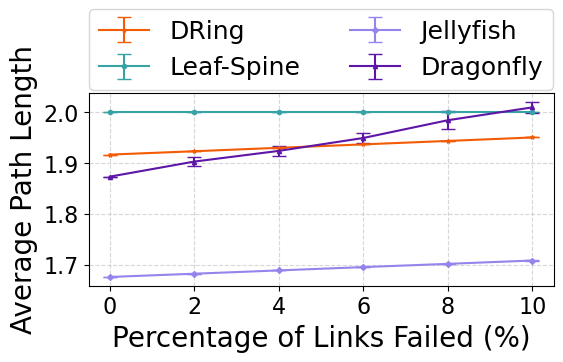

In [30]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

plot_order = ["dring", "leafspine", "rrg", "df2"]
markers = ['*', 'o', 'D', '^']
labelnames = {
    "leafspine": "Leaf-Spine",
    "dring": "DRing",
    "rrg": "Jellyfish",
    "df2": "Dragonfly"
}

# Starting points
starting_points = {
    "leafspine": 2,
    "dring": 1.9165,
    "rrg": 1.6759,
    "df2": 1.8731
}

# Parse data.txt
data = defaultdict(lambda: defaultdict(list))  # data[graph][failpct] = list of avgplen

with open("data.txt") as f:
    for line in f:
        tokens = line.strip().split()
        graph = tokens[1]
        failpct = int(tokens[3])
        avgplen = float(tokens[7])
        data[graph][failpct].append(avgplen)

# Plotting
fig, ax = plt.subplots(figsize=(6, 2.5))
colors = ['#f35b04', '#38a3a5', '#9683ec', '#5d16a6']

for i,graph in enumerate(plot_order):
    failpct_dict = data[graph]
    failpcts = sorted(failpct_dict.keys())
    means = []
    stds = []

    for pct in failpcts:
        vals = failpct_dict[pct]
        means.append(np.mean(vals))
        stds.append(np.std(vals))

    # Add starting point
    failpcts = [0] + failpcts
    means = [starting_points[graph]] + means
    stds = [0] + stds

    ax.errorbar(failpcts, means, yerr=stds, label=labelnames[graph], color=colors[i], marker=markers[i], markersize=3, capsize=5)

ax.set_xlabel("Percentage of Links Failed (%)",fontsize=20)
ax.set_ylabel("Average Path Length",fontsize=20)
# ax.set_title("Average Path Length vs. Failure Percentage")
ax.tick_params(axis='both', labelsize=16)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper center',fontsize=18,ncol=2,bbox_to_anchor=(0.5, 1.5))
# plt.tight_layout()
plt.savefig(f"design_fail.pdf", dpi=600, bbox_inches='tight')
# plt.show()
